In [ ]:
!pip install pandas scikit-learn matplotlib tqdm seaborn --break-system-packages

In [71]:
from sklearn import datasets, tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tqdm import trange

In [2]:
data = datasets.load_wine()
data.feature_names, data.target_names

(['alcohol',
  'malic_acid',
  'ash',
  'alcalinity_of_ash',
  'magnesium',
  'total_phenols',
  'flavanoids',
  'nonflavanoid_phenols',
  'proanthocyanins',
  'color_intensity',
  'hue',
  'od280/od315_of_diluted_wines',
  'proline'],
 array(['class_0', 'class_1', 'class_2'], dtype='<U7'))

In [3]:
df = pd.DataFrame(columns=data.feature_names, data=data.data)
df["target"] = data.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
df.target.unique()

array([0, 1, 2])

In [5]:
print(data.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

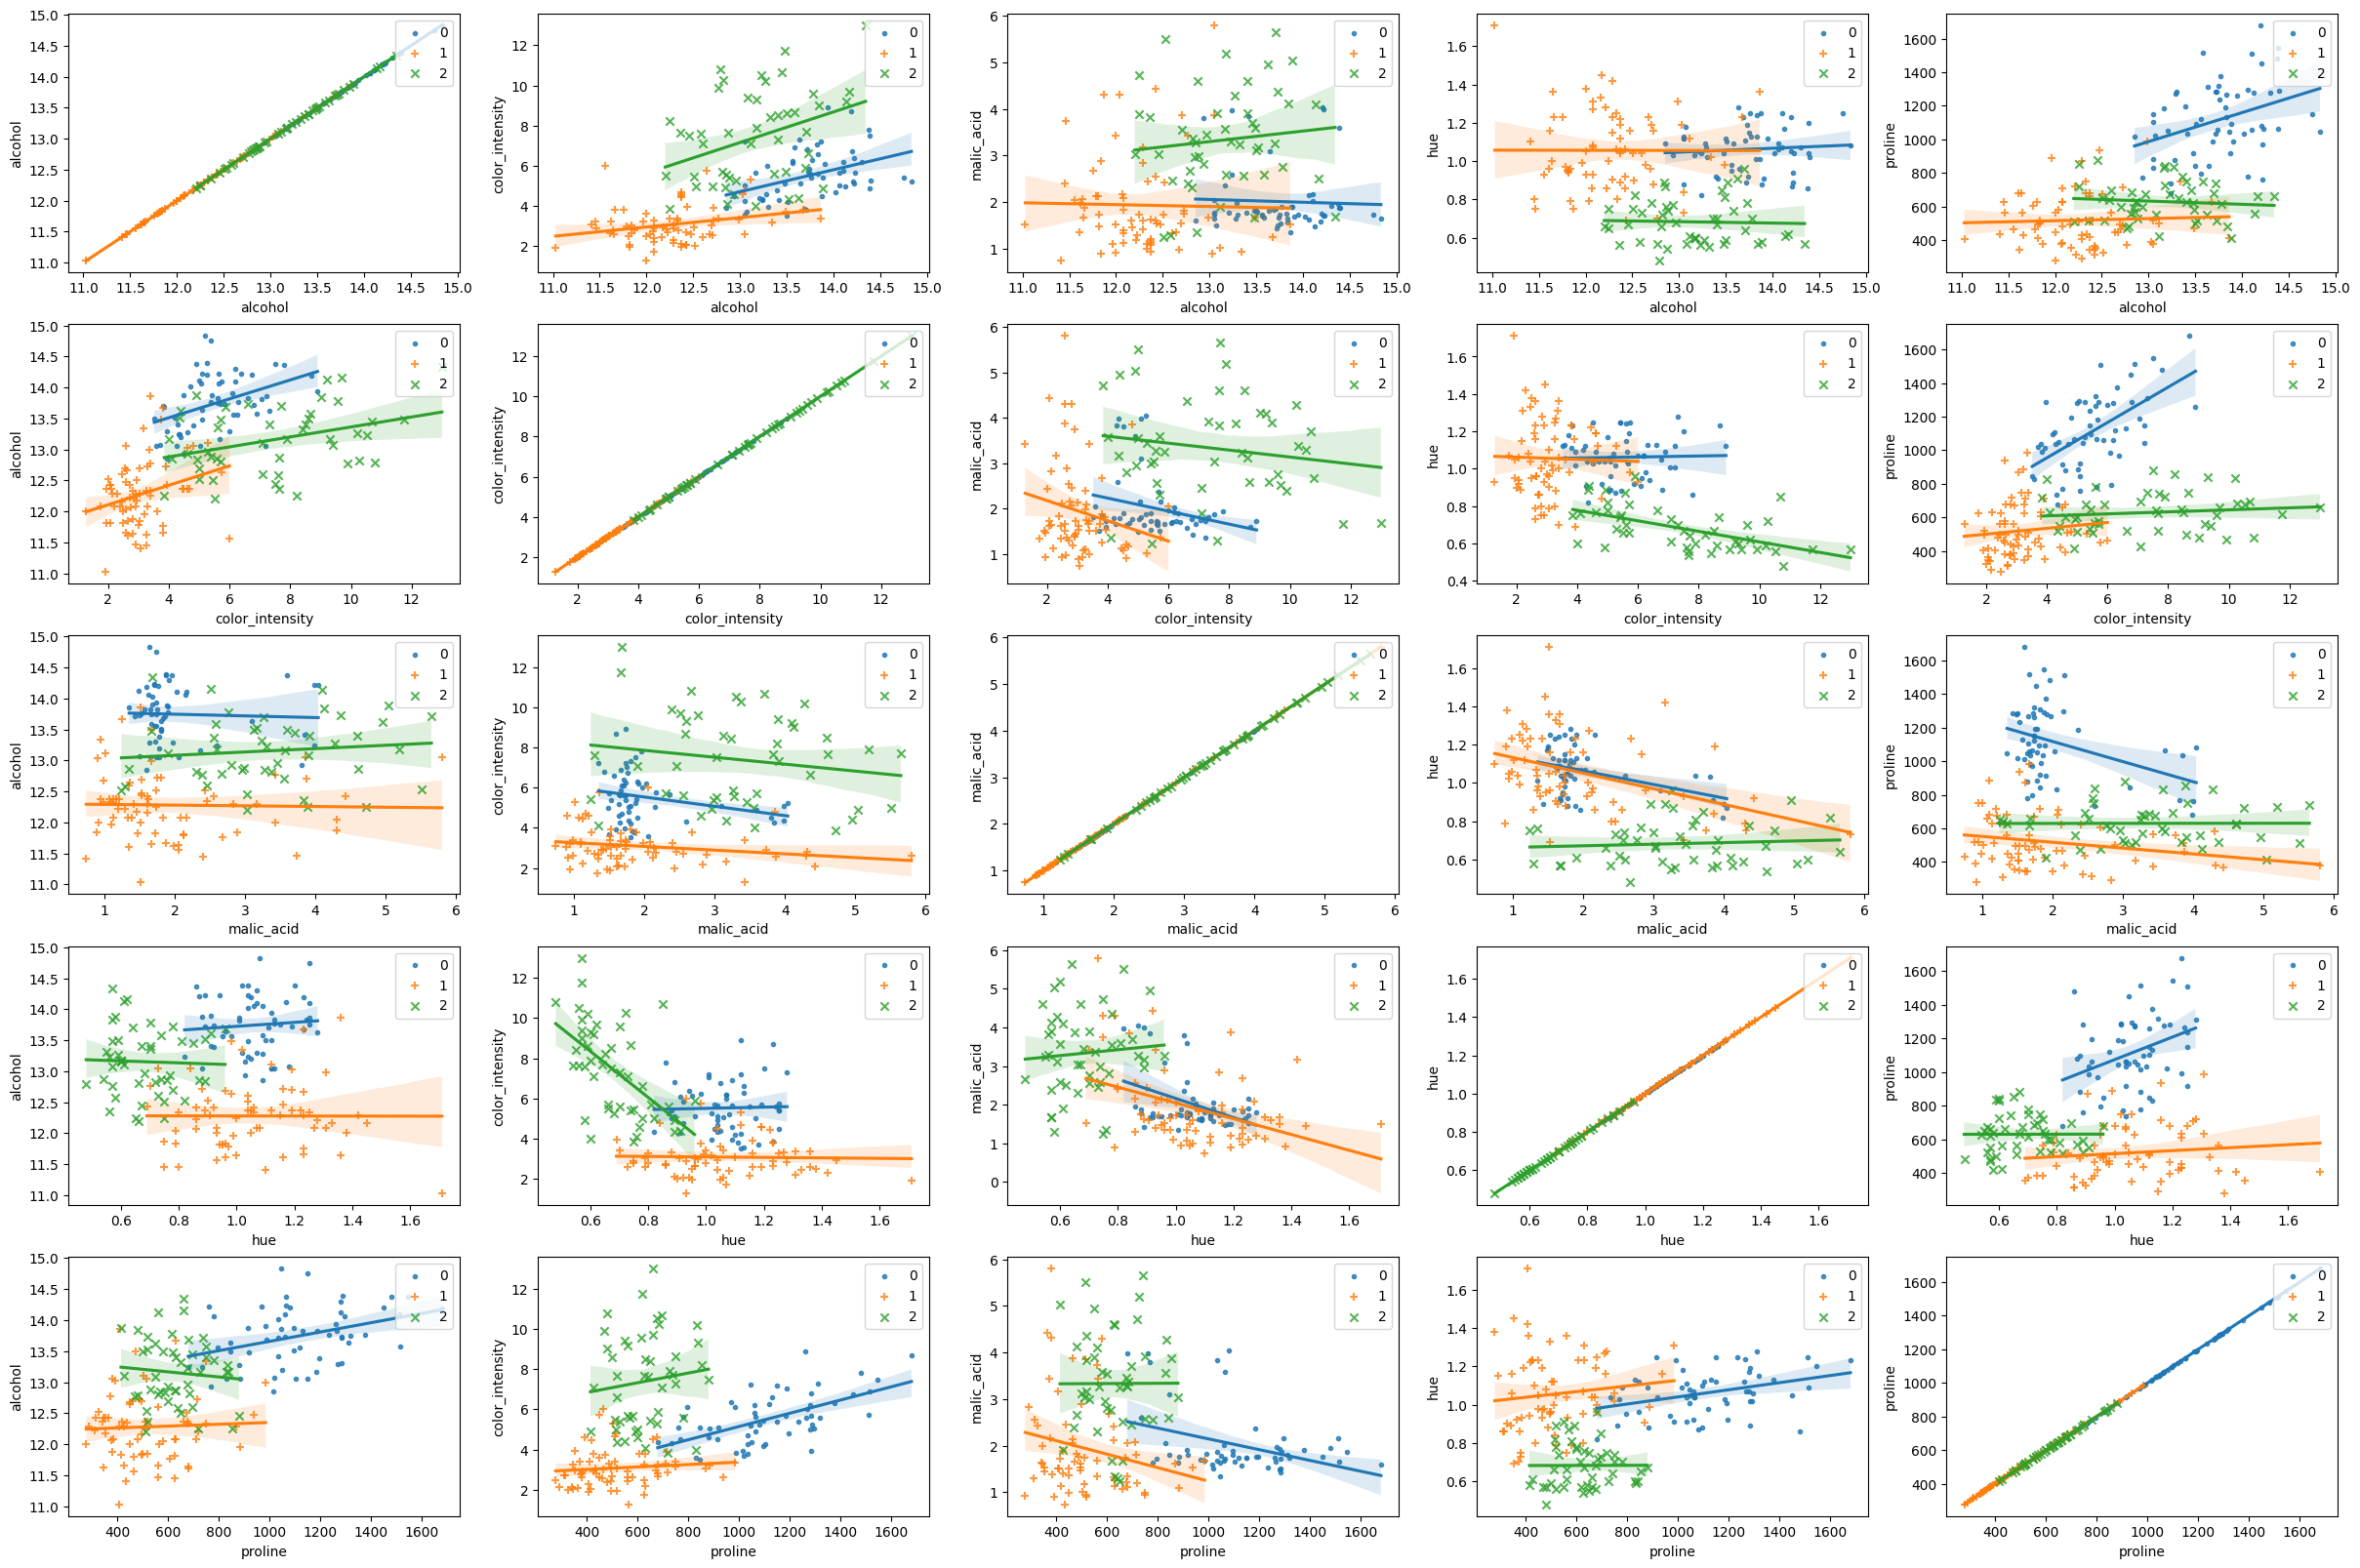

In [6]:
selected_columns = ["alcohol", "color_intensity", "malic_acid", "hue","proline"]
t_columns = len(selected_columns)

fig,ax = plt.subplots(t_columns, t_columns,figsize=(30,20))

for i,row in enumerate(selected_columns):
    for j,col in enumerate(selected_columns):

        for marker,label in zip(('.', '+', 'x'), (0,1,2)):
            sns.regplot(data=df[df.target==label], x=row, y=col, ax=ax[i,j], marker=marker, label=label)
            ax[i,j].legend(loc='upper right')

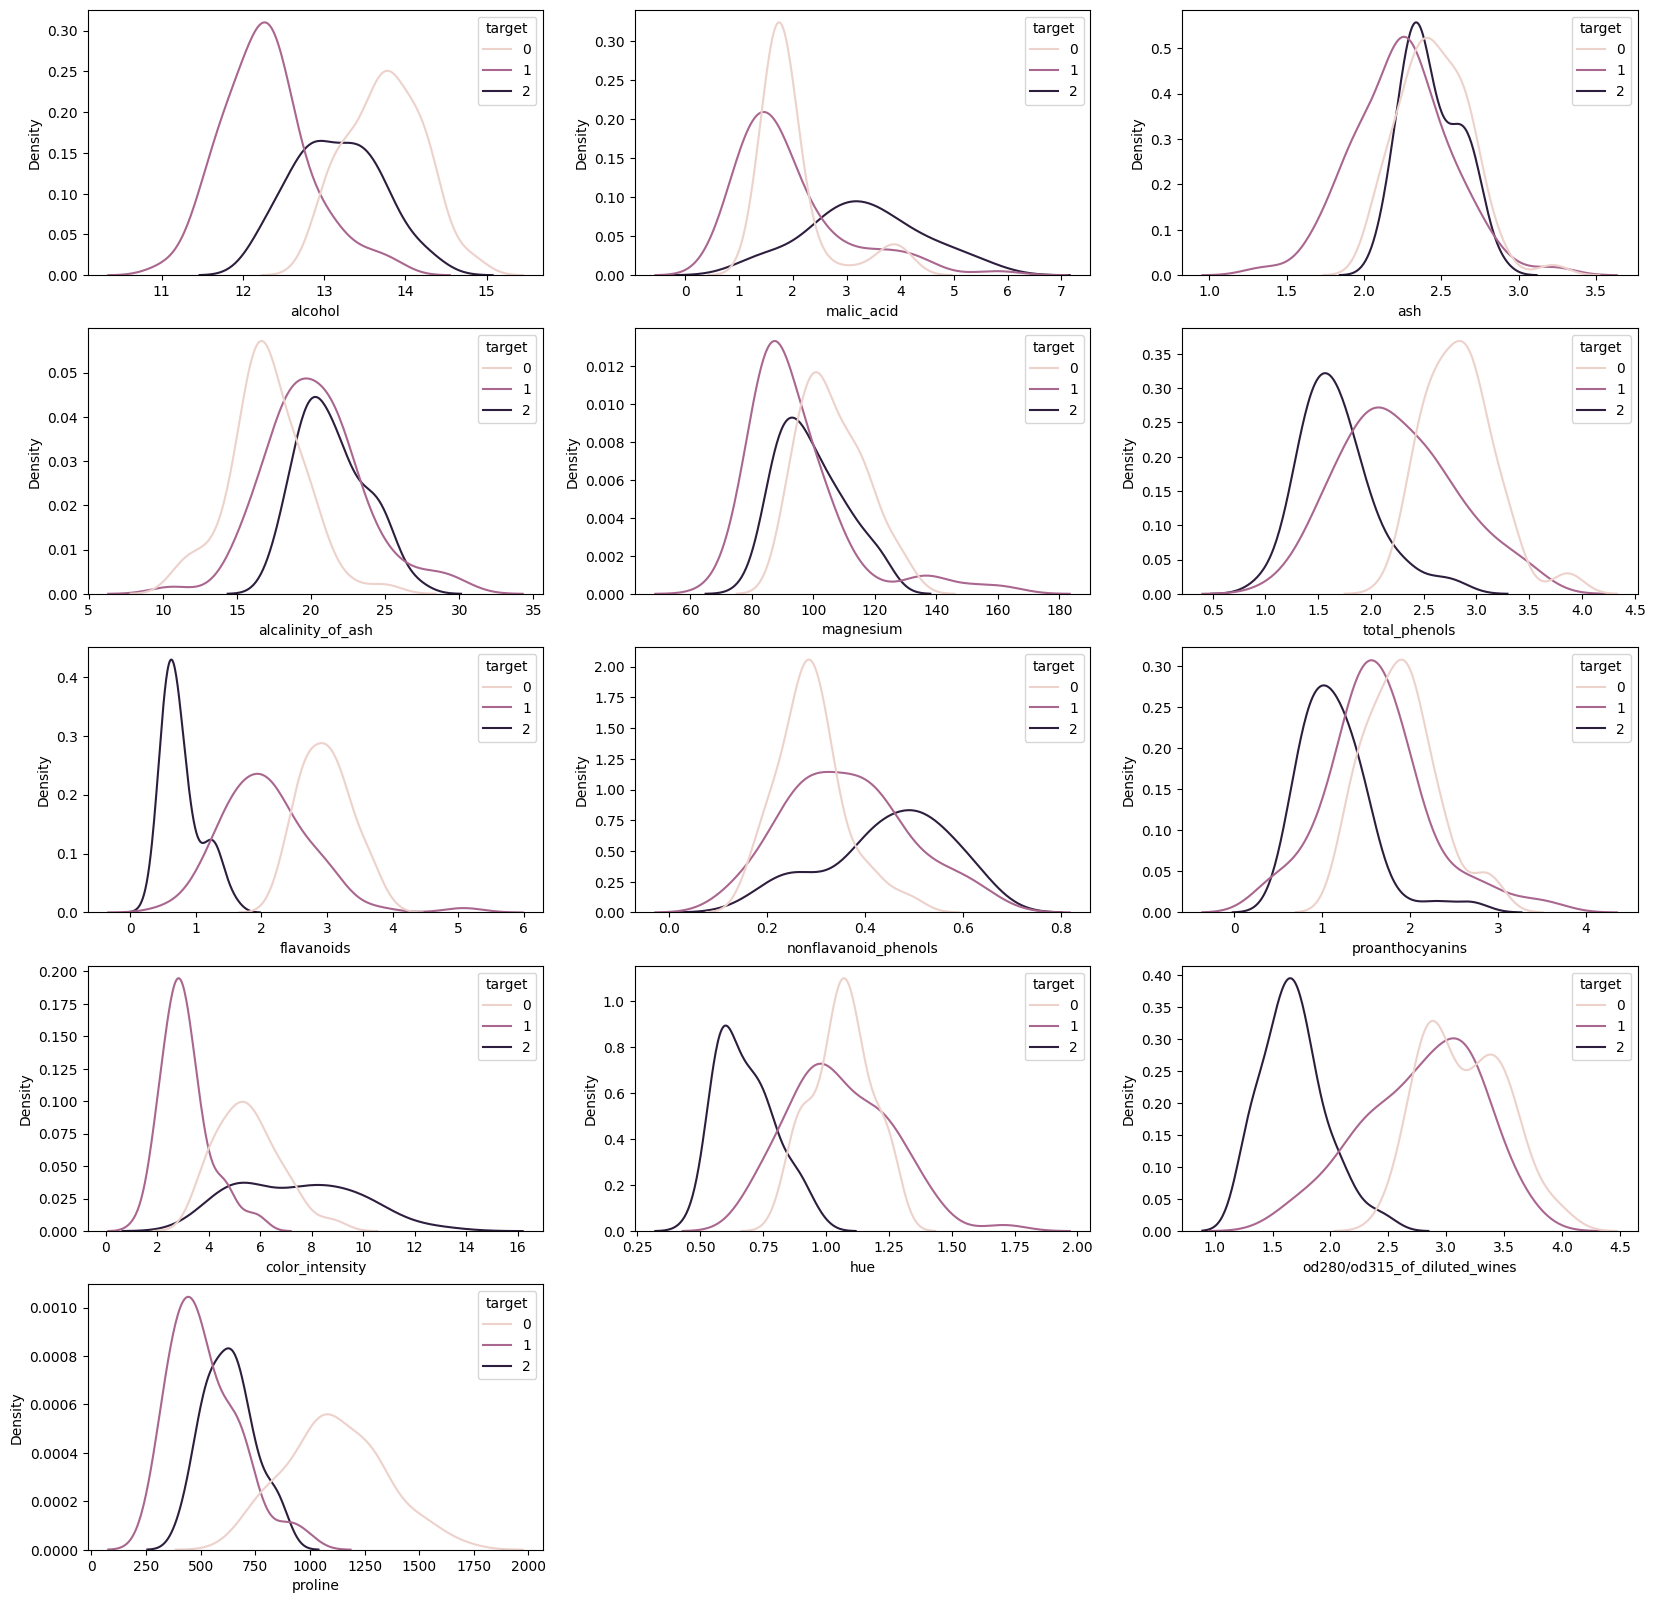

In [17]:
cols = data.feature_names
t_cols = len(cols)
n_cols = 3
n_rows = math.ceil(t_cols/n_cols)

plt.figure(figsize=(20,20))

for i,col in enumerate(cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.kdeplot(data=df,x=col,hue="target")

In [72]:
best_model = None
best_accuracy = 0
selected_features = []
pred = None
target_data = None

gen_comb_label = lambda comb:' + '.join(comb)

hipotesis = [["hue", "color_intensity", "alcohol"], ["hue", "malic_acid", "alcohol"], ["proline", "color_intensity", "alcohol"], ["proline", "malic_acid", "color_intensity"], ['od280/od315_of_diluted_wines', 'proline', 'alcohol']]
columns = [gen_comb_label(comb) for comb in hipotesis]
accuracy_data = pd.DataFrame(columns=columns)
i_loc = 0

tests = 1000


for _ in trange(tests):

    acc_data = {col:0 for col in columns }
    
    for comb in hipotesis:
        comb_label = gen_comb_label(comb)
        X = df[comb]
        y = data.target

        X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

        model = tree.DecisionTreeClassifier()
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        acurracy = accuracy_score(y_test, y_pred)

        acc_data[comb_label] = acurracy

        if(acurracy > best_accuracy):
            best_accuracy = acurracy
            best_model = deepcopy(model)
            selected_features = comb
            pred = y_pred
            target_data = y_test


    accuracy_data.loc[i_loc] = acc_data
    i_loc += 1


100%|██████████| 1000/1000 [00:17<00:00, 57.91it/s]


<Axes: >

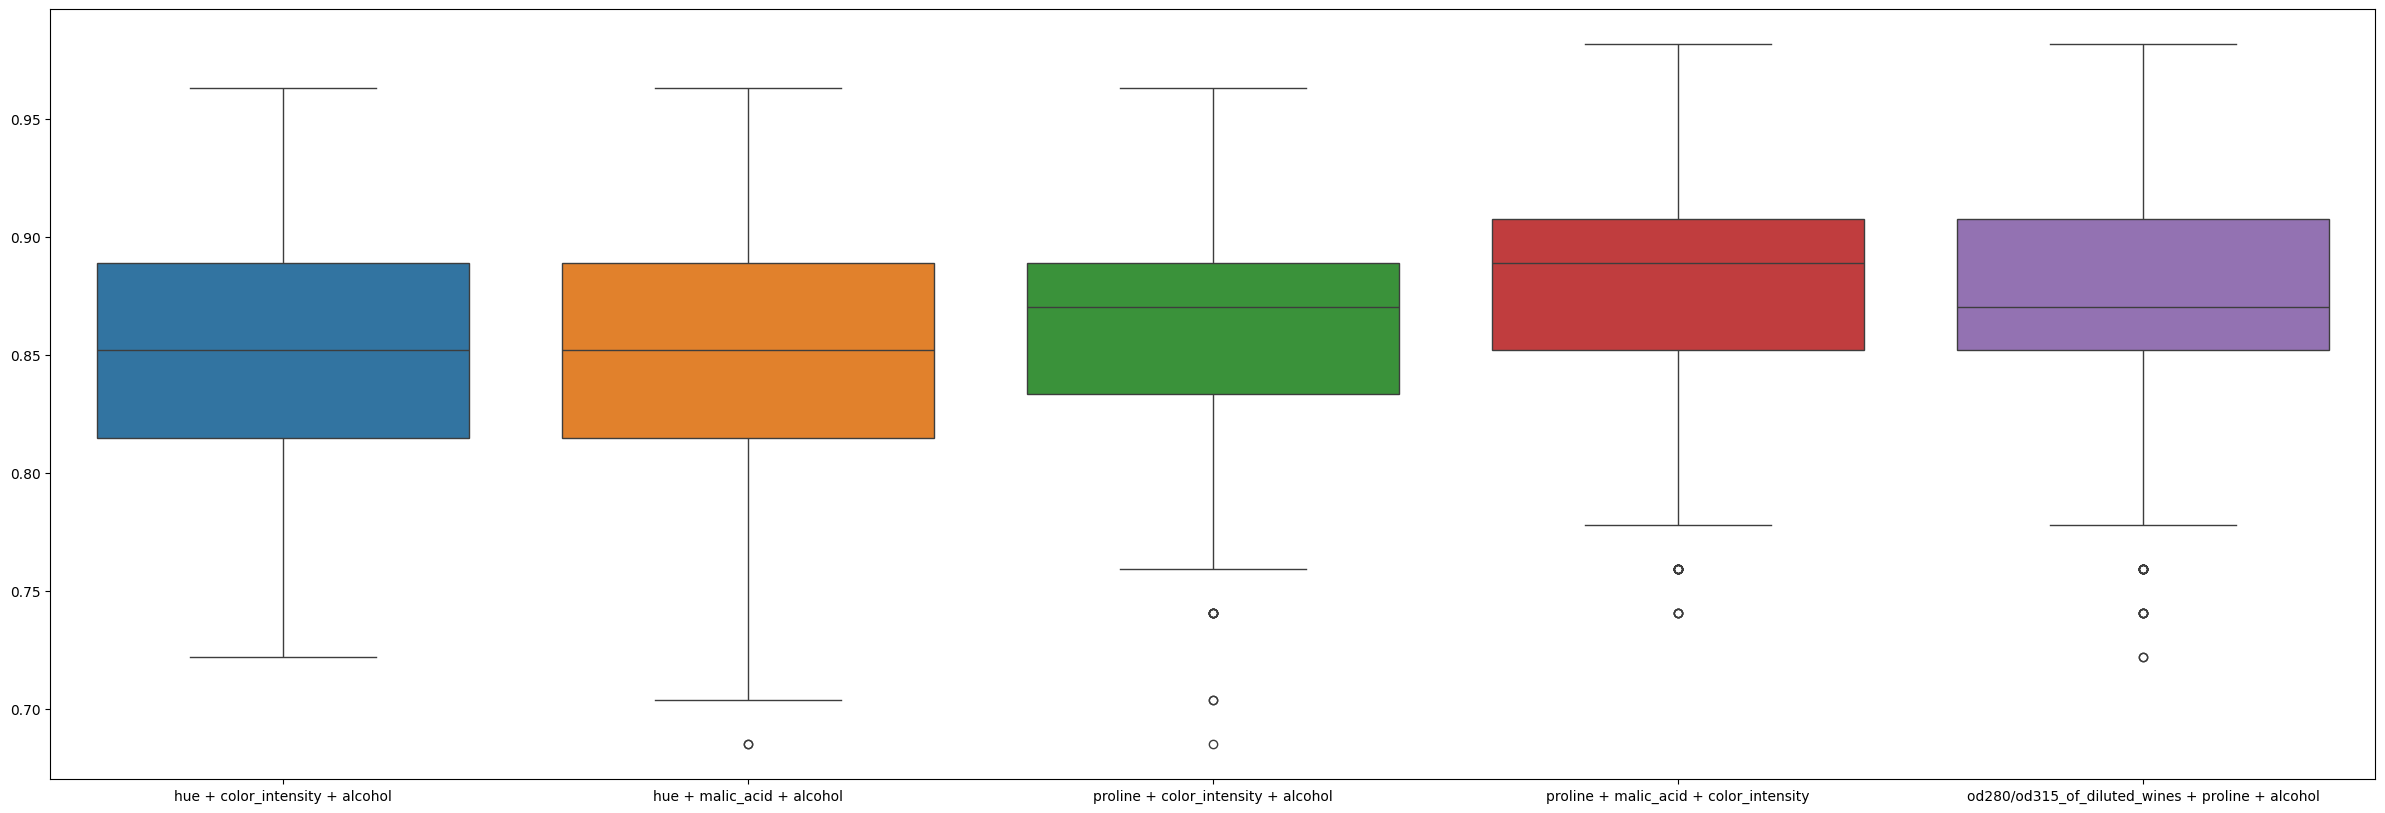

In [73]:
plt.figure(figsize=(30,10))
sns.boxplot(data=accuracy_data)

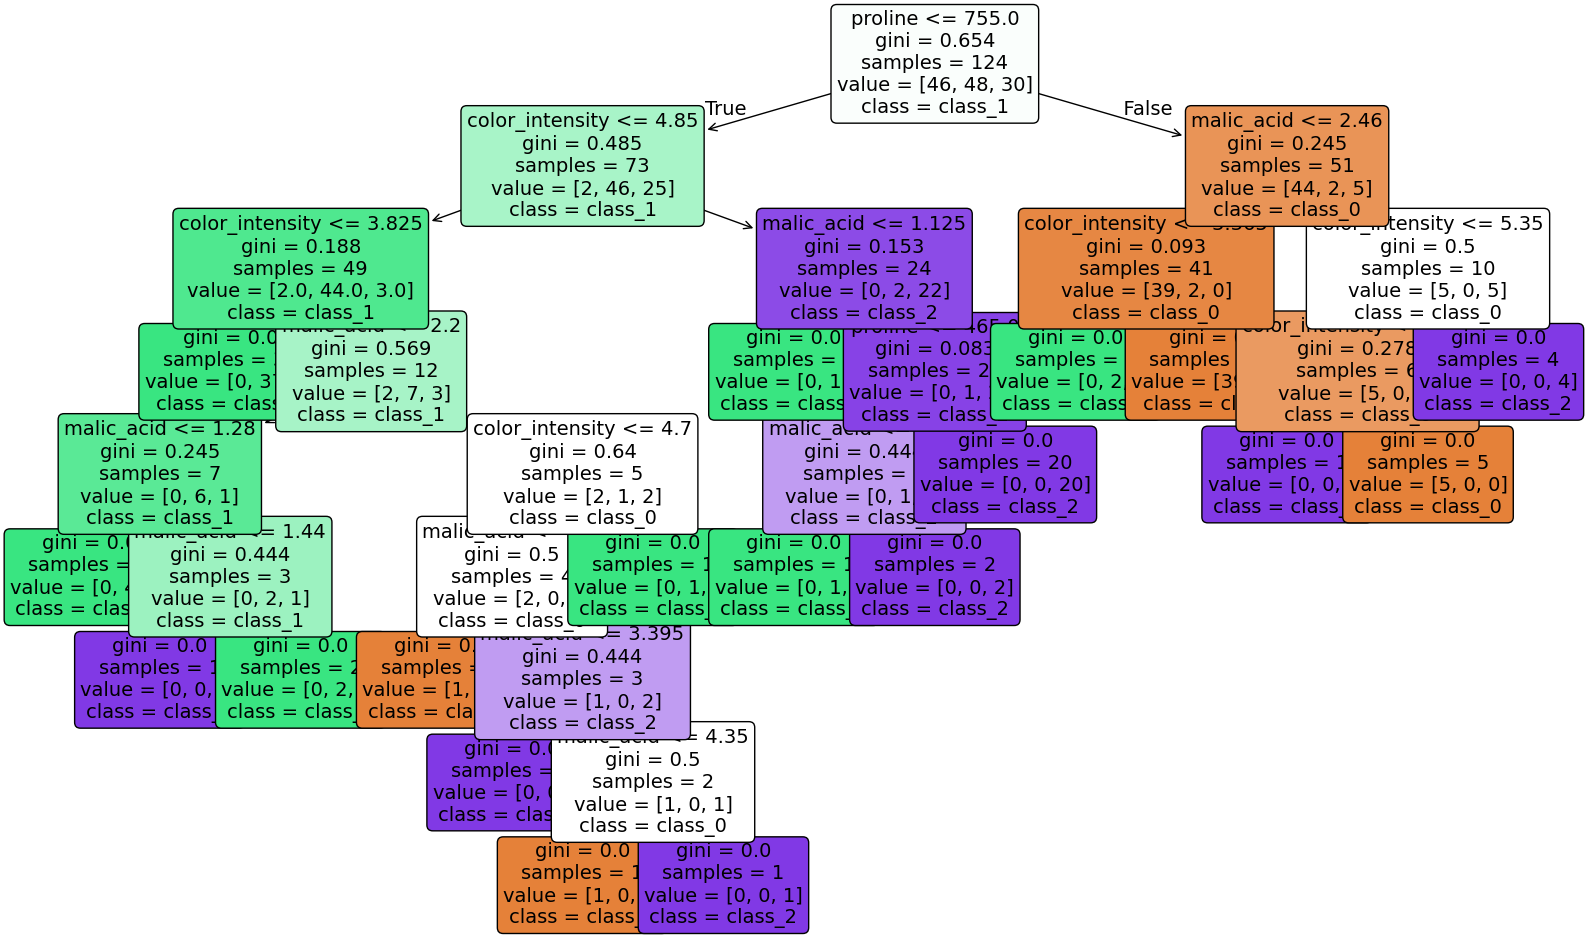

In [74]:
plt.figure(figsize=(20,12))
g = tree.plot_tree(best_model, 
               feature_names=selected_features, 
               class_names=data.target_names,
                rounded=True, 
               filled=True, 
               fontsize=14
              )

In [77]:
print("Melhor acurácia dos testes: ", best_accuracy)
print("Melhor combinação: ", selected_features)
print(classification_report(target_data, pred))

Melhor acurácia dos testes:  0.9814814814814815
Melhor combinação:  ['proline', 'malic_acid', 'color_intensity']
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.96      0.98        23
           2       0.95      1.00      0.97        18

    accuracy                           0.98        54
   macro avg       0.98      0.99      0.98        54
weighted avg       0.98      0.98      0.98        54

